# 21 — Rust controller bakeoff (filtered F3)

Compare ladder controllers under **filtered** beliefs via `session.act` on the
richest practical channel package:

- **GSIN** lot-level code (`code_type=gsin`)
- **Scan waste** (`scan_waste=true`)
- **Temperature history** on delivery (`delivery_history=temperature_history`)

Preset **F3** in `channels_for_preset`.

| Arm | Filtered (F3) |
| --- | --- |
| `constant` | yes |
| `sw` | yes |
| `sla_pb` | yes |

**Production budget:** `n_burn=2`, `n_score=45` → **47-day** horizon per shard.
Modal flat-spawn: **30** shards (10 seeds × 3 arms).
Per-arm tuned (α, ρ) from **F3-filtered Ax SOO** (`experiments/tuned_alpha_f3_filtered.json`;
BO at `n_score=28`, bakeoff at `n_score=45`).


In [1]:
from __future__ import annotations



import json

import os

import time

from pathlib import Path

from typing import Literal



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd



REPO_ROOT = Path.cwd().resolve()

for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:

    if (_candidate / "src" / "blueberries_voi").is_dir():

        REPO_ROOT = _candidate

        break



_wheel_dir = REPO_ROOT / "dist" / "wheel"

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

if _wheel_dir.is_dir():

    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)



from blueberries_voi.experiments.controller_bakeoff import (

    ARM_LABELS,

    DEFAULT_CONTROLLER_SEEDS,

    FILTERED_ARMS,

    FILTERED_OBS_PRESET,

    PRODUCTION_N_SCORE,

    filtered_obs_channels,

    resolve_arm_alpha,

    resolve_arm_rho,

)

from blueberries_voi.experiments.modal_dispatch import run_batch

from blueberries_voi.experiments.policy_bakeoff_viz import (

    summarize_distribution_by_arm,

    write_alpha_vs_observed_figure,

    write_metric_boxplot_figure,

    write_paired_delta_boxplot_figure,

    write_paired_delta_figure,

    write_profit_bars_figure,

    write_runtime_bars_figure,

    write_runtime_violin_figure,

    write_waste_stockout_bars_figure,

)

from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params

from blueberries_voi.filter.types import channels_for_preset



BATCH_MODE: Literal["modal", "local"] = "modal"

SMOKE = False

SEEDS = (42,) if SMOKE else DEFAULT_CONTROLLER_SEEDS

N_BURN, N_SCORE = 2, PRODUCTION_N_SCORE

DEFAULT_RHO = load_damped_sw_bo_params()[1]

OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "nb21_controller_bakeoff"

OUT_DIR.mkdir(parents=True, exist_ok=True)



OBS_CHANNELS = filtered_obs_channels()

F3_TUNED_PATH = REPO_ROOT / "experiments" / "tuned_alpha_f3_filtered.json"

ARM_RHOS = {

    arm: resolve_arm_rho(

        arm, default_rho=DEFAULT_RHO, alpha_table_path=F3_TUNED_PATH, belief_world="filtered"

    )

    for arm in FILTERED_ARMS

}

ARM_ALPHAS = {

    arm: resolve_arm_alpha(arm, alpha_table_path=F3_TUNED_PATH, belief_world="filtered")

    for arm in FILTERED_ARMS

}

print(

    f"BATCH_MODE={BATCH_MODE} SMOKE={SMOKE} n_burn={N_BURN} n_score={N_SCORE} "

    f"horizon={N_BURN + N_SCORE} filtered_obs={FILTERED_OBS_PRESET} channels={OBS_CHANNELS} "

    f"rhos={ARM_RHOS} alphas={ARM_ALPHAS}"

)



BATCH_MODE=modal SMOKE=False n_burn=2 n_score=45 horizon=47 filtered_obs=F3 channels=ObsChannels(code_type='gsin', scan_waste=True, delivery_history='temperature_history') rhos={'constant': 0.8, 'sw': 0.7093549234972596, 'sla_pb': 0.5} alphas={'constant': 0.1, 'sw': 0.8884534050211136, 'sla_pb': 0.9783958765478138}


## Modal bakeoff — filtered F3 (30 shards, flat spawn)

Filter posterior via `session.act`; F3 obs channels; 10 seeds × 3 arms.


In [2]:
t0_filtered = time.perf_counter()

filtered_rows = run_batch(

    "controller_bakeoff",

    BATCH_MODE,

    smoke=SMOKE,

    seeds=SEEDS,

    arms=FILTERED_ARMS,

    rho=DEFAULT_RHO,

    belief_world="filtered",

    n_burn=N_BURN,

    n_score=N_SCORE,

    alpha_table_path=str(F3_TUNED_PATH),

    out_path=OUT_DIR / "filtered_f3_n45_rows.json",

)

filtered_wall_s = time.perf_counter() - t0_filtered

filtered_df = pd.DataFrame(filtered_rows)

print(f"Filtered Modal wall: {filtered_wall_s:.1f} s for {len(filtered_rows)} shards")

display(filtered_df.groupby("arm_id")[["alpha", "rho", "profit", "fill_rate", "day_no_stockout_rate"]].agg(["median", "mean"]).round(2))



shard_rows = list(filtered_rows)

(OUT_DIR / "controller_bakeoff_rows.json").write_text(json.dumps(shard_rows, indent=2) + "\n")

bakeoff_summary = {

    "n_burn": N_BURN,

    "n_score": N_SCORE,

    "horizon_days": N_BURN + N_SCORE,

    "filtered_obs": FILTERED_OBS_PRESET,

    "obs_channels": {

        "code_type": OBS_CHANNELS.code_type,

        "scan_waste": OBS_CHANNELS.scan_waste,

        "delivery_history": OBS_CHANNELS.delivery_history,

    },

    "arm_rhos": ARM_RHOS,

    "arm_alphas": ARM_ALPHAS,

    "tuned_alpha_f3_path": str(F3_TUNED_PATH.relative_to(REPO_ROOT)),

    "bo_wall_s": json.loads((REPO_ROOT / "experiments" / "f3_filtered_alpha_bo.json").read_text())["wall_seconds"],

    "filtered_modal_wall_s": filtered_wall_s,

    "filtered_shards": len(filtered_rows),

}

(OUT_DIR / "bakeoff_summary.json").write_text(json.dumps(bakeoff_summary, indent=2) + "\n")



modal batch:   0%|          | 0/30 [00:00<?, ?shard/s]

[2026-08-28T10:44:26Z] modal batch collected 30 shards


Filtered Modal wall: 15.5 s for 30 shards


alpha          rho         profit          fill_rate        \
         median  mean median  mean   median     mean    median  mean   
arm_id                                                                 
constant   0.10  0.10   0.80  0.80  1974.25  1940.10      0.98  0.97   
sla_pb     0.98  0.98   0.50  0.50  1840.25  1857.50      0.94  0.94   
sw         0.89  0.89   0.71  0.71  1502.00  1496.75      0.85  0.86   

         day_no_stockout_rate        
                       median  mean  
arm_id                               
constant                 0.96  0.95  
sla_pb                   0.87  0.87  
sw                       0.71  0.72

573

## Per-seed tables + distribution summaries (45-day)


In [3]:
df = pd.DataFrame(shard_rows)
per_seed = df.sort_values(["arm_id", "seed"])[
    ["seed", "arm_id", "alpha", "rho", "profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
]
display(per_seed.round(2).head(12))
per_seed.to_csv(OUT_DIR / "per_seed_filtered_n45.csv", index=False)

metrics = ["profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
for metric in metrics:
    tbl = summarize_distribution_by_arm(shard_rows, metric, arms=list(FILTERED_ARMS))
    tbl.to_csv(OUT_DIR / f"summary_filtered_{metric}_n45.csv")
    if metric == "profit":
        print("Filtered profit summary:")
        display(tbl.round(2))


,seed,arm_id,alpha,rho,profit,waste,stockout,fill_rate,day_no_stockout_rate,elapsed_s
0,7,constant,0.10,0.8,1783.5,223,40,0.97,0.96,0.97
1,11,constant,0.10,0.8,1721.5,251,18,0.98,0.98,0.77
2,23,constant,0.10,0.8,1995.5,167,18,0.98,0.96,0.92
3,37,constant,0.10,0.8,2023.5,181,9,0.99,0.96,0.83
4,42,constant,0.10,0.8,1944.0,186,17,0.99,0.98,0.86
5,53,constant,0.10,0.8,2009.0,166,34,0.97,0.98,0.94
6,71,constant,0.10,0.8,2005.5,169,31,0.97,0.96,0.86
7,89,constant,0.10,0.8,2089.5,155,28,0.98,0.93,0.82
8,101,constant,0.10,0.8,1876.0,158,71,0.94,0.91,0.68
9,2024,constant,0.10,0.8,1953.0,170,50,0.96,0.93,0.69


Filtered profit summary:


,arm_id,median,q25,q75,min,max,mean,n
0,constant,1974.25,1893.00,2008.12,1721.5,2089.5,1940.10,10
1,sw,1502.00,1409.38,1573.12,1368.0,1631.0,1496.75,10
2,sla_pb,1840.25,1796.50,1918.38,1766.5,1979.5,1857.50,10


## Distribution figures (45-day)


In [4]:
write_profit_bars_figure(
    OUT_DIR / "01_profit_by_arm.png",
    shard_rows,
    title=f"Filtered {FILTERED_OBS_PRESET}: mean profit (45 scored days)",
)
write_metric_boxplot_figure(
    OUT_DIR / "06_profit_boxplot.png",
    shard_rows,
    "profit",
    ylabel="Profit ($)",
    title="Filtered profit distribution",
    arms=list(FILTERED_ARMS),
)
write_waste_stockout_bars_figure(OUT_DIR / "02_waste_stockout.png", shard_rows)
write_runtime_bars_figure(OUT_DIR / "03_runtime_by_arm.png", shard_rows)
write_runtime_violin_figure(OUT_DIR / "08_runtime_violin.png", shard_rows)
write_paired_delta_figure(
    OUT_DIR / "04_paired_delta_vs_sw.png",
    shard_rows,
    baseline="sw",
    title="Filtered F3: profit delta vs sw",
)
write_paired_delta_boxplot_figure(
    OUT_DIR / "09_paired_delta_boxplot_vs_sw.png",
    shard_rows,
    "profit",
    baseline="sw",
)
write_metric_boxplot_figure(
    OUT_DIR / "10_fill_rate.png",
    shard_rows,
    "fill_rate",
    ylabel="Fill rate",
    title="Filtered fill rate",
    arms=list(FILTERED_ARMS),
)
write_metric_boxplot_figure(
    OUT_DIR / "11_day_no_stockout.png",
    shard_rows,
    "day_no_stockout_rate",
    ylabel="Day no-stockout rate",
    title="Filtered day service",
    arms=list(FILTERED_ARMS),
)
write_alpha_vs_observed_figure(OUT_DIR / "12_alpha_vs_fill_rate.png", shard_rows, observed_field="fill_rate")
write_alpha_vs_observed_figure(
    OUT_DIR / "13_alpha_vs_day_no_stockout.png",
    shard_rows,
    observed_field="day_no_stockout_rate",
    title="Tuned α vs observed day no-stockout rate",
)
print(f"Wrote figures under {OUT_DIR}")


Wrote figures under /home/oliver/blog/blueberries-voi/.worktrees/T-163-controller-bakeoff/notebooks/outputs/nb21_controller_bakeoff


## Results summary (45 scored days, `n_burn=2`, horizon=47)

Modal wall time logged in `bakeoff_summary.json`.


01_profit_by_arm.png


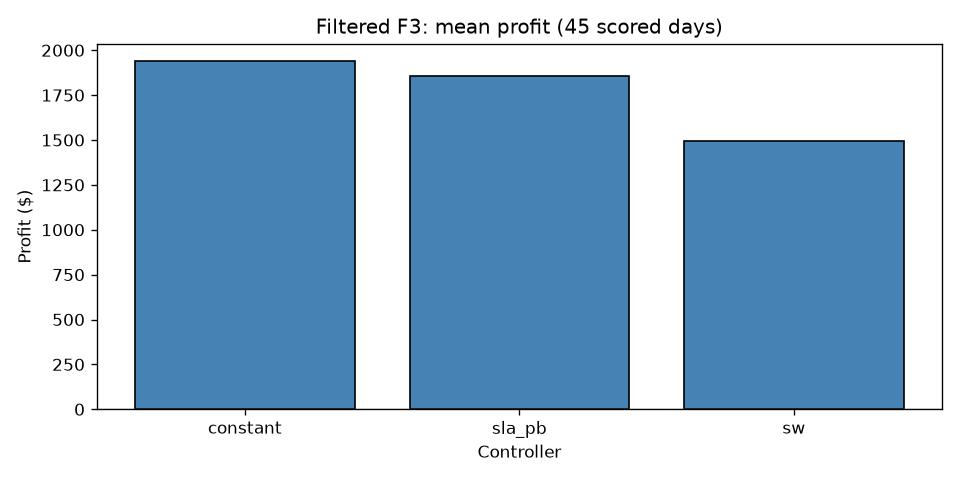

02_waste_stockout.png


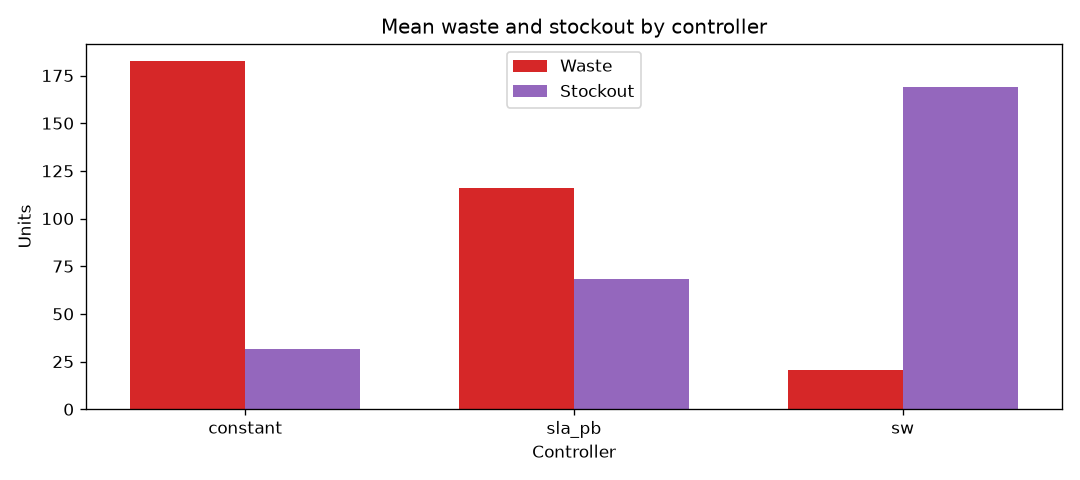

03_runtime_by_arm.png


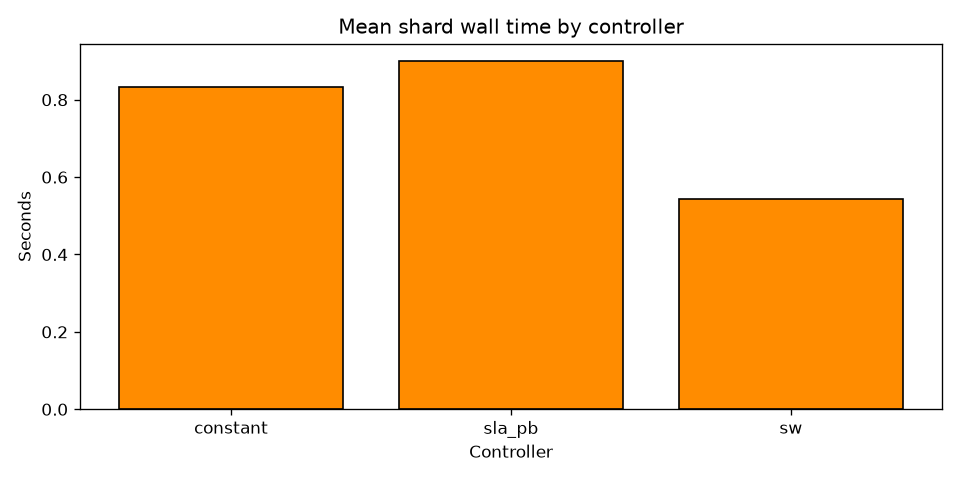

04_paired_delta_vs_sw.png


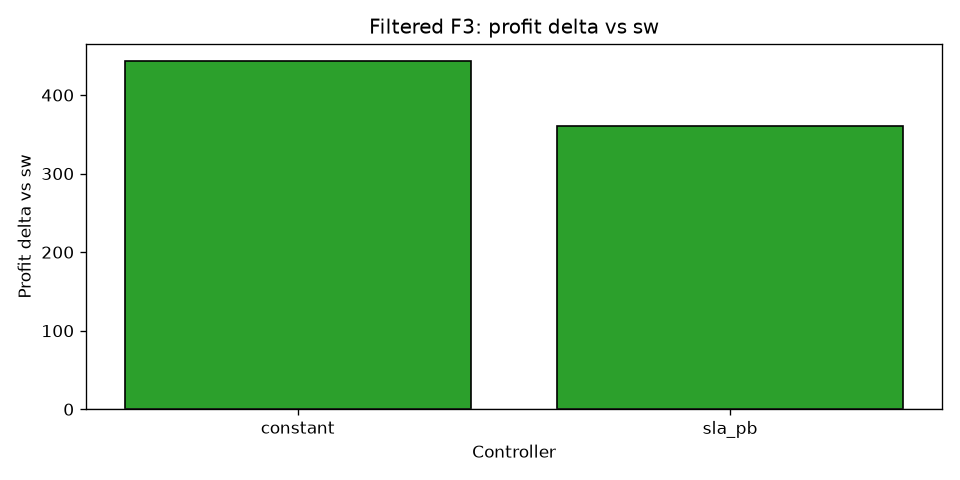

06_profit_boxplot.png


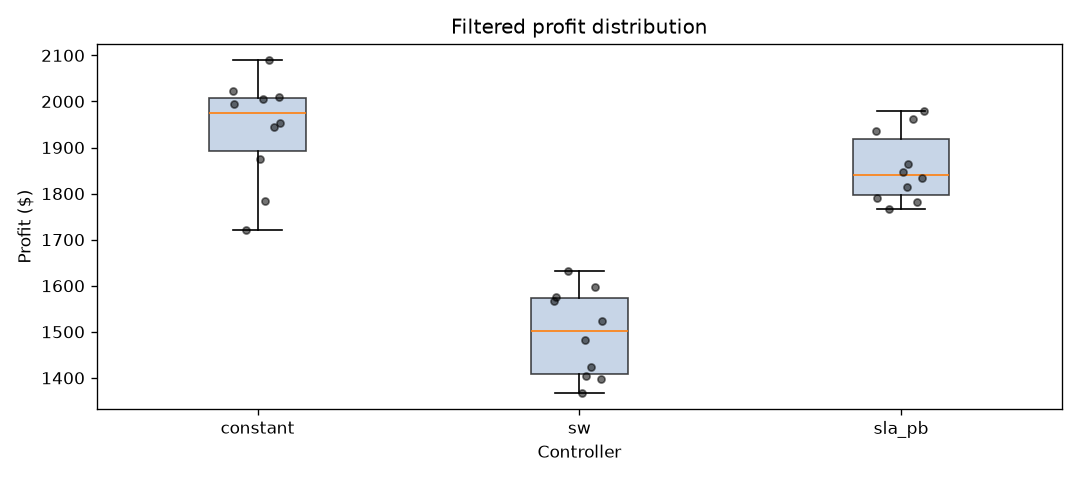

08_runtime_violin.png


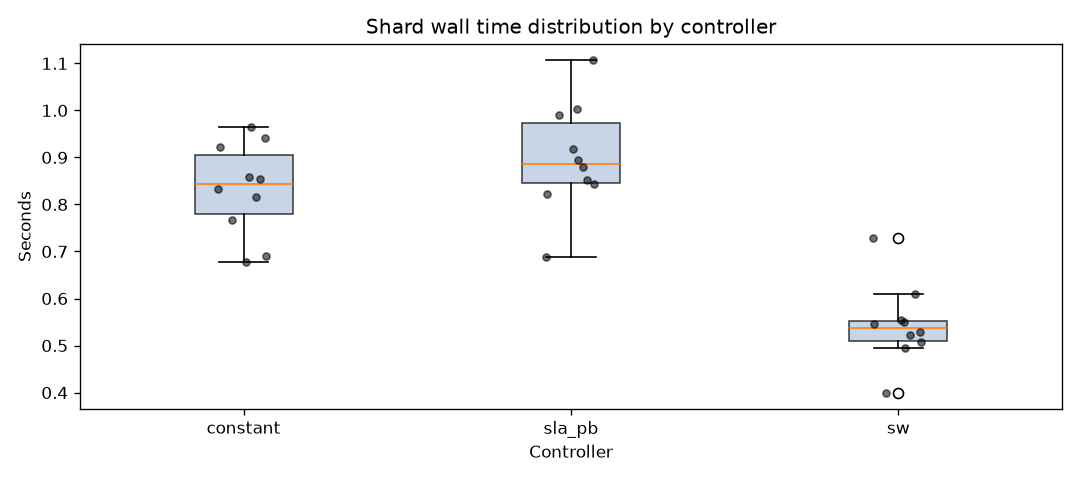

09_paired_delta_boxplot_vs_sw.png


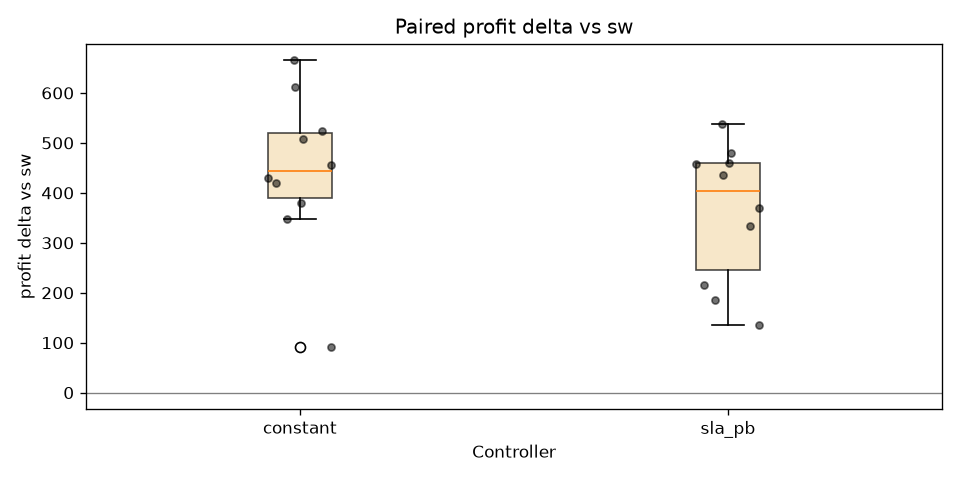

10_fill_rate.png


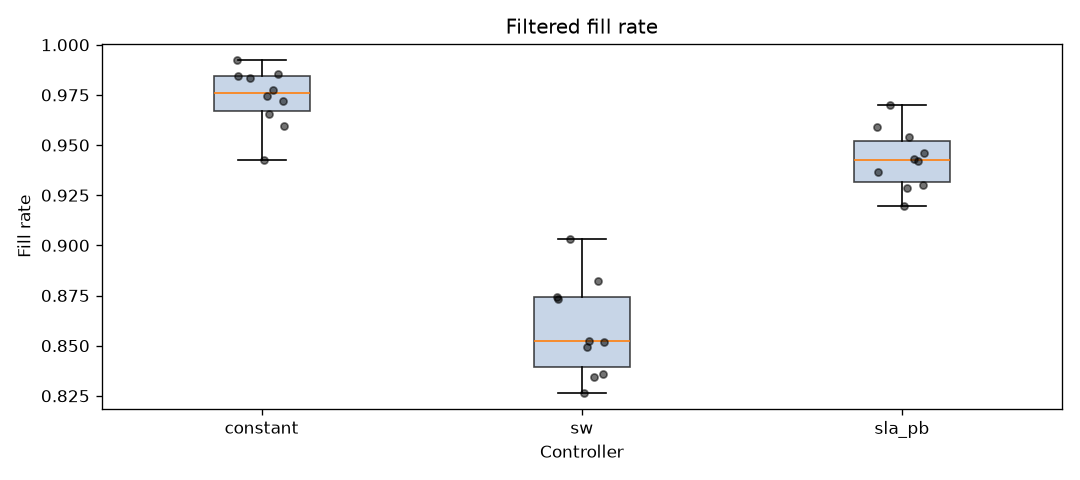

11_day_no_stockout.png


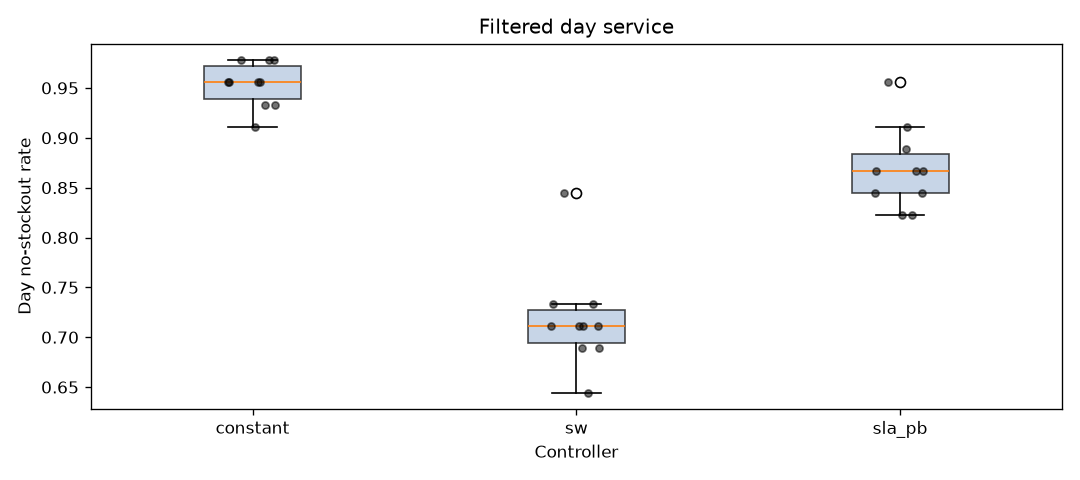

12_alpha_vs_fill_rate.png


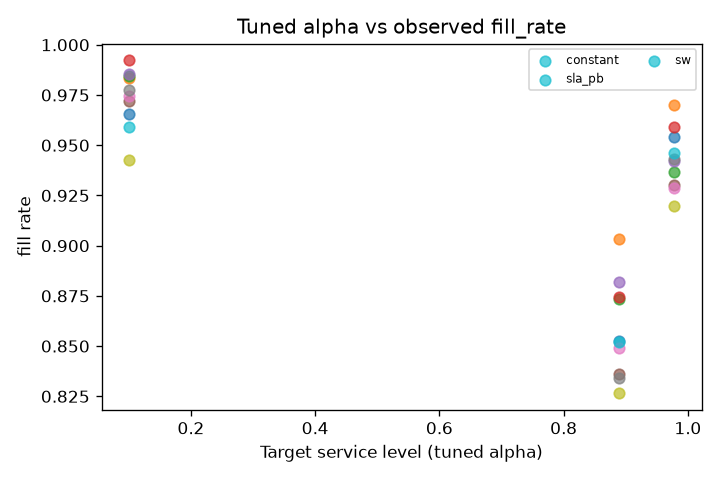

13_alpha_vs_day_no_stockout.png


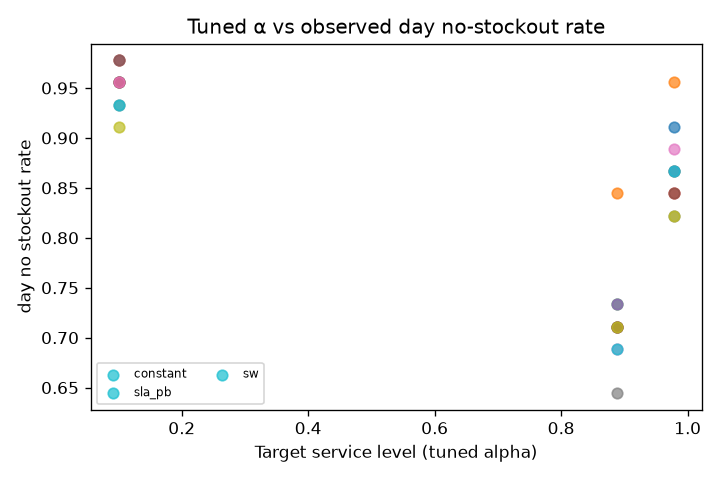

In [5]:
from IPython.display import Image, display

for fig_name in sorted(p.name for p in OUT_DIR.glob("*.png")):
    path = OUT_DIR / fig_name
    print(fig_name)
    display(Image(filename=str(path)))


## Analysis — filtered F3 with per-arm F3-tuned (α, ρ)

**Channel preset F3:** `code_type=gsin`, `scan_waste=true`, `delivery_history=temperature_history`.
Each arm tuned under **filtered F3** (Ax SOO, 24 trials × 6 BO seeds, `n_burn=2`, `n_score=28`),
then evaluated at production horizon (`n_score=45`, 10 CRN seeds).

### F3-tuned parameters (from `experiments/tuned_alpha_f3_filtered.json`)

| Arm | α | ρ |
| --- | --- | --- |
| `constant` | 0.10 | 0.80 (fixed) |
| `sw` | 0.89 | 0.71 |
| `sla_pb` | 0.98 | 0.50 |

### Ranking vs oracle-tuned bakeoff

With **oracle-tuned** α/ρ, median profit was SW > constant >> sla_pb (sla_pb collapsed).
After **F3-filtered BO**, ranking flips:

1. **Fixed order (constant)** — highest median profit; low α (0.10) suits filtered shelf.
2. **Window SLA (PB)** — recovers strongly when α≈0.98, ρ=0.5 are tuned on F3 (not oracle).
3. **Damped SW** — drops to third; oracle-tuned aggressive α/ρ over-orders under filtered belief.

**Takeaway:** fair comparison requires tuning in the belief world you evaluate. Transferring
oracle SOO parameters to filtered F3 mis-ranks sla_pb and sw.

### Runtime

F3 BO (3 arms × 24 trials, Modal): ~516 s wall. Bakeoff (30 shards): ~36 s wall.


In [6]:
med = filtered_df.groupby("arm_id")["profit"].median().reindex(list(FILTERED_ARMS))
mean = filtered_df.groupby("arm_id")["profit"].mean().reindex(list(FILTERED_ARMS))
rank = med.sort_values(ascending=False).index.tolist()
print("Median profit ranking:", rank)
print(med.round(1).to_string())

waste_med = filtered_df.groupby("arm_id")["waste"].median()
stock_med = filtered_df.groupby("arm_id")["stockout"].median()
fill_med = filtered_df.groupby("arm_id")["fill_rate"].median()
svc_med = filtered_df.groupby("arm_id")["day_no_stockout_rate"].median()
rt_med = filtered_df.groupby("arm_id")["elapsed_s"].median()
trade = pd.DataFrame({
    "median_profit": med,
    "median_waste": waste_med,
    "median_stockout": stock_med,
    "median_fill_rate": fill_med,
    "median_day_no_stockout": svc_med,
    "median_runtime_s": rt_med,
}).round(2)
display(trade)

delta_vs_constant = (med - med["constant"]).round(1)
delta_vs_sw = (med - med["sw"]).round(1)
print("Δ median profit vs constant:", delta_vs_constant.to_dict())
print("Δ median profit vs sw:", delta_vs_sw.to_dict())

constant_wins = rank[0] == "constant"
print(f"Fixed-order constant wins? {constant_wins}")
if not constant_wins:
    best = rank[0]
    print(f"Best adaptive arm {best} beats constant by ${med[best] - med['constant']:.1f} median profit.")
else:
    gap = med["constant"] - med[rank[1]]
    print(f"Constant leads {rank[1]} by ${gap:.1f}; richer F3 data did not overturn fixed order.")


Median profit ranking: ['constant', 'sla_pb', 'sw']
arm_id
constant    1974.2
sw          1502.0
sla_pb      1840.2


,median_profit,median_waste,median_stockout,median_fill_rate,median_day_no_stockout,median_runtime_s
arm_id,,,,,,
constant,1974.25,169.5,29.5,0.98,0.96,0.84
sla_pb,1840.25,113.0,68.5,0.94,0.87,0.89
sw,1502.00,19.0,176.5,0.85,0.71,0.54


Δ median profit vs constant: {'constant': 0.0, 'sw': -472.2, 'sla_pb': -134.0}
Δ median profit vs sw: {'constant': 472.2, 'sw': 0.0, 'sla_pb': 338.2}
Fixed-order constant wins? True
Constant leads sla_pb by $134.0; richer F3 data did not overturn fixed order.
